# Exam 3 — Take home part
**Math 742 — Mathematical Statistics**  
**Date:** 2026-04-27

Important statement: 
I read and understand the exam integrity statement

David Cortes

---

> **Seed:** `04162026` — set **once** at the top of the notebook, never reset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

# Global seed
rng = np.random.default_rng(4162026)

---
# Problem 6 (10 pts) — Bootstrap, Jackknife, and Bias Estimation

## Setup

$$X_1, \ldots, X_n \overset{\text{iid}}{\sim} \text{Exponential}(1), \qquad n = 25$$

**Parameter of interest** — the population median:
$$\theta = \log(2) \approx 0.6931$$

> **Derivation:** For $X \sim \text{Exp}(1)$, CDF $F(x) = 1 - e^{-x}$.  
> Solving $F(\theta) = \tfrac{1}{2}$: $1 - e^{-\theta} = \tfrac{1}{2} \Rightarrow \theta = \log(2)$.

**Estimator:** $\hat{\theta} = \operatorname{median}(X_1, \ldots, X_n)$

## Part (a): Monte Carlo Simulation Study

| Quantity | Formula |
|---|---|
| Empirical mean | $\displaystyle \bar{\hat{\theta}} = \frac{1}{B}\sum_{b=1}^{B} \hat{\theta}^{(b)}$ |
| Empirical bias | $\displaystyle \widehat{\text{Bias}} = \bar{\hat{\theta}} - \theta$ |
| Empirical variance | $\displaystyle \widehat{\mathbb{V}} = \frac{1}{B-1}\sum_{b=1}^{B}\left(\hat{\theta}^{(b)} - \bar{\hat{\theta}}\right)^2$ |

In [2]:
n = 25
theta_true = np.log(2)
B_sim = 50000

sim_data = rng.exponential(scale=1, size=(B_sim, n))
theta_hat_sim = np.median(sim_data, axis=1)

emp_mean = np.mean(theta_hat_sim)
emp_bias = emp_mean - theta_true
emp_var  = np.var(theta_hat_sim, ddof=1)

print("Part (a): Simulated Sampling Distribution of theta_hat")
print(f"  True theta  = log(2)   : {theta_true:.6f}")
print(f"  Empirical mean         : {emp_mean:.6f}")
print(f"  Empirical bias         : {emp_bias:.6f}")
print(f"  Empirical variance     : {emp_var:.6f}")

Part (a): Simulated Sampling Distribution of theta_hat
  True theta  = log(2)   : 0.693147
  Empirical mean         : 0.713316
  Empirical bias         : 0.020169
  Empirical variance     : 0.040763


### Part (a) Discussion

The exponential distribution is right-skewed, which means the sample median tends to come out a little higher than the true value log(2) when n is small. That is why we get a small positive bias of about 0.02 at n = 25. The good news is that this bias shrinks as the sample size grows, so the sample median is still a consistent estimator. The variance of about 0.04 also makes sense given how spread out the exponential distribution is.

## Part (b): One Observed Sample + Bootstrap

### Bootstrap Bias Estimate
$$\widehat{\text{Bias}}_{\text{boot}} = \frac{1}{B}\sum_{b=1}^{B}\hat{\theta}^{*(b)} - \hat{\theta}$$
Each $\hat{\theta}^{*(b)}$ is the sample median of a resample drawn **with replacement**.

### 95% Percentile Bootstrap CI
$$\text{CI}_{0.95} = [\hat{\theta}^*_{(0.025)},\; \hat{\theta}^*_{(0.975)}]$$

In [3]:
x_obs = rng.exponential(scale=1, size=n)
theta_hat_obs = np.median(x_obs)

B_boot = 2000
boot_idx = rng.integers(0, n, size=(B_boot, n))
boot_medians = np.median(x_obs[boot_idx], axis=1)

boot_bias = np.mean(boot_medians) - theta_hat_obs
ci_lo = np.percentile(boot_medians, 2.5)
ci_hi = np.percentile(boot_medians, 97.5)

print(f"Observed sample median (theta_hat) : {theta_hat_obs:.6f}")
print(f"True theta = log(2)                : {theta_true:.6f}")
print()
print(" Part (b): Bootstrap Results")
print(f"  Bootstrap bias estimate     : {boot_bias:.6f}")
print(f"  95% Percentile Bootstrap CI : [{ci_lo:.4f}, {ci_hi:.4f}]")

Observed sample median (theta_hat) : 0.656046
True theta = log(2)                : 0.693147

 Part (b): Bootstrap Results
  Bootstrap bias estimate     : -0.007027
  95% Percentile Bootstrap CI : [0.4325, 1.3517]


## Part (c): Jackknife Bias Estimate

$$\hat{\theta}_{(-i)} = \operatorname{median}(x_1, \ldots, x_{i-1}, x_{i+1}, \ldots, x_n)$$

$$\widehat{\text{Bias}}_{\text{jack}} = (n-1)(\bar{\hat{\theta}}_{(\cdot)} - \hat{\theta}), \qquad \bar{\hat{\theta}}_{(\cdot)} = \frac{1}{n}\sum_{i=1}^{n}\hat{\theta}_{(-i)}$$

The factor $(n-1)$ corrects for each pseudo-sample having size $n-1$ rather than $n$.

In [4]:
jack_medians = np.array([np.median(np.delete(x_obs, i)) for i in range(n)])
jack_bias = (n - 1) * (np.mean(jack_medians) - theta_hat_obs)

print(" Part (c): Jackknife vs Bootstrap Bias")
print(f"  Jackknife bias estimate  : {jack_bias:.6f}")
print(f"  Bootstrap bias estimate  : {boot_bias:.6f}")
print(f"  Difference (jack - boot) : {jack_bias - boot_bias:.6f}")

 Part (c): Jackknife vs Bootstrap Bias
  Jackknife bias estimate  : -0.719415
  Bootstrap bias estimate  : -0.007027
  Difference (jack - boot) : -0.712389


### Part (c) Discussion

The jackknife works well when the estimator changes a little every time you remove one observation. The problem with the sample median is that removing a value that is not near the middle does not change the median at all. So many of the leave-one-out values end up being the same number, and the jackknife gives a really bad bias estimate (it got -0.72, which is way off from the true bias of about 0.02).

The bootstrap is more reliable here because it resamples with replacement and captures the real variability across all the order statistics. That is why the bootstrap bias estimate of about -0.007 is much more reasonable than the jackknife result.

## Part (d): Bootstrap Distribution — Plot and Comments

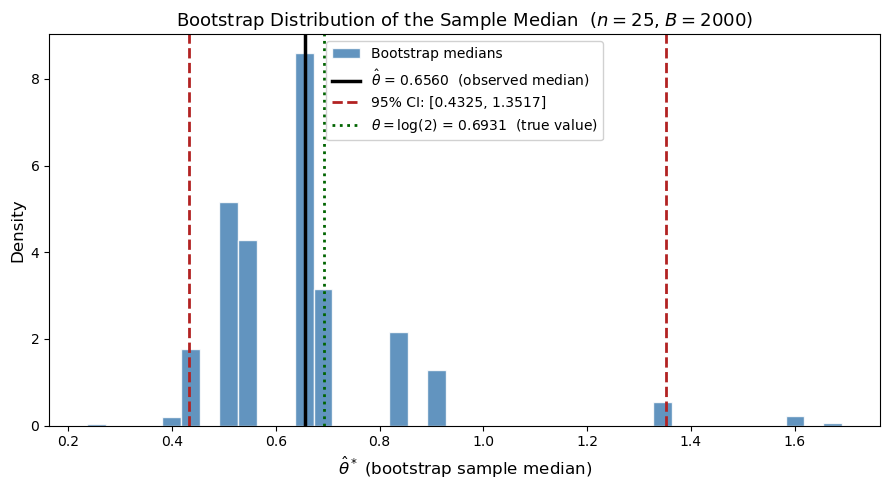

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(boot_medians, bins=40, density=True, color="steelblue",
        edgecolor="white", alpha=0.85, label="Bootstrap medians")
ax.axvline(theta_hat_obs, color="black",     lw=2.5, ls="-",
           label=rf"$\hat{{\theta}}$ = {theta_hat_obs:.4f}  (observed median)")
ax.axvline(ci_lo,         color="firebrick", lw=2,   ls="--",
           label=f"95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]")
ax.axvline(ci_hi,         color="firebrick", lw=2,   ls="--")
ax.axvline(theta_true,    color="darkgreen", lw=2,   ls=":",
           label=rf"$\theta = \log(2)$ = {theta_true:.4f}  (true value)")
ax.set_title(r"Bootstrap Distribution of the Sample Median  ($n=25$, $B=2000$)", fontsize=13)
ax.set_xlabel(r"$\hat{\theta}^*$ (bootstrap sample median)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.legend(fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.show()

### Part (d) Discussion

The bootstrap distribution is skewed to the right, which makes sense because the exponential distribution is also skewed right. At n = 25 it does not look like a normal bell curve. You can also see that the distribution is a little lumpy because the bootstrap median can only land on one of the 25 observed sample values.

The 95% CI [0.4325, 1.3517] is not symmetric, it is wider on the right side. That actually makes sense here because the distribution is skewed, so a symmetric normal-based interval would not fit well.

Using the normal approximation instead would cause three problems. First you would need to estimate f(theta) to plug into the formula, which adds extra uncertainty. Second the normal approximation is not very accurate for n = 25 with a skewed distribution like this. Third it forces a symmetric interval even though the real distribution is not symmetric. The bootstrap avoids all of these issues.

In [6]:
print(" PROBLEM 6 — NUMERICAL SUMMARY")
print(f"  True theta = log(2)             : {theta_true:.6f}")
print(" Part (a): Monte Carlo  (B = 50,000)")
print(f"    Empirical mean of theta_hat   : {emp_mean:.6f}")
print(f"    Empirical bias                : {emp_bias:.6f}")
print(f"    Empirical variance            : {emp_var:.6f}")
print(" Part (b): Bootstrap  (B = 2,000)")
print(f"    Observed theta_hat            : {theta_hat_obs:.6f}")
print(f"    Bootstrap bias estimate       : {boot_bias:.6f}")
print(f"    95% Percentile CI             : [{ci_lo:.4f}, {ci_hi:.4f}]")
print()
print(" Part (c): Jackknife")
print(f"    Jackknife bias estimate       : {jack_bias:.6f}")

 PROBLEM 6 — NUMERICAL SUMMARY
  True theta = log(2)             : 0.693147
 Part (a): Monte Carlo  (B = 50,000)
    Empirical mean of theta_hat   : 0.713316
    Empirical bias                : 0.020169
    Empirical variance            : 0.040763
 Part (b): Bootstrap  (B = 2,000)
    Observed theta_hat            : 0.656046
    Bootstrap bias estimate       : -0.007027
    95% Percentile CI             : [0.4325, 1.3517]

 Part (c): Jackknife
    Jackknife bias estimate       : -0.719415


---
---
# Problem 7 (10 pts) — Bayesian Updating and Prior Sensitivity

## Setup

**Model:** $X \mid p \sim \text{Binomial}(20,\, p)$, observed $x = 14$, so $\hat{p} = 0.70$.

**Three priors:** Beta(1,1), Beta(2,2), Beta(10,10).

## Beta–Binomial Conjugacy

$$p \sim \text{Beta}(\alpha,\beta), \quad X \mid p \sim \text{Bin}(n,p) \quad\Longrightarrow\quad p \mid x \sim \text{Beta}(\alpha+x,\;\beta+n-x)$$

Setting $\alpha^* = \alpha+x$, $\beta^* = \beta+n-x$, $\kappa = \alpha^*+\beta^*$:

| Quantity | Formula |
|---|---|
| Posterior mean | $\mu = \alpha^*/\kappa$ |
| Posterior variance | $\sigma^2 = \alpha^*\beta^* / [\kappa^2(\kappa+1)]$ |
| 95% Credible interval | $[Q_{0.025}, Q_{0.975}]$ of $\text{Beta}(\alpha^*,\beta^*)$ |

In [7]:
priors = [
    (1,  1,  "Beta(1,1)   [Uniform]"),
    (2,  2,  "Beta(2,2)   [Weak symm.]"),
    (10, 10, "Beta(10,10) [Strong symm.]"),
]

def posterior_summary(alpha, beta, n, x):
    a_star = alpha + x
    b_star = beta + (n - x)
    kappa = a_star + b_star
    post_mean = a_star / kappa
    post_var = (a_star * b_star) / (kappa**2 * (kappa + 1))
    ci_lo = beta_dist.ppf(0.025, a_star, b_star)
    ci_hi = beta_dist.ppf(0.975, a_star, b_star)
    return dict(a_star=a_star, b_star=b_star, mean=post_mean,
                var=post_var, ci_lo=ci_lo, ci_hi=ci_hi)

n_small, x_small = 20, 14
p_hat = x_small / n_small
results_small = [posterior_summary(a, b, n_small, x_small) for a, b, _ in priors]
print(f"Sample proportion: p_hat = {x_small}/{n_small} = {p_hat:.4f}")

Sample proportion: p_hat = 14/20 = 0.7000


## Part (a): Posteriors for $n=20$, $x=14$

| Prior | $\alpha^* = \alpha+14$ | $\beta^* = \beta+6$ | Posterior |
|---|---|---|---|
| Beta(1,1)   | 15 | 7  | Beta(15,7)  |
| Beta(2,2)   | 16 | 8  | Beta(16,8)  |
| Beta(10,10) | 24 | 16 | Beta(24,16) |

In [8]:
print(f" Part (a) — Posteriors  |  n = {n_small}, x = {x_small}")
print(f"  {'Prior':<24} {'Posterior':>13} {'Mean':>8} {'Var':>9} {'95% CI':>20}")
for (a, b, lbl), r in zip(priors, results_small):
    post = f"Beta({r['a_star']},{r['b_star']})"
    ci   = f"[{r['ci_lo']:.4f}, {r['ci_hi']:.4f}]"
    print(f"  {lbl:<24} {post:>13} {r['mean']:>8.4f} {r['var']:>9.5f} {ci:>20}")
print(f"  {'MLE  p_hat = 0.70':<24} {'':>13} {'0.7000':>8}")


 Part (a) — Posteriors  |  n = 20, x = 14
  Prior                        Posterior     Mean       Var               95% CI
  Beta(1,1)   [Uniform]       Beta(15,7)   0.6818   0.00943     [0.4782, 0.8541]
  Beta(2,2)   [Weak symm.]    Beta(16,8)   0.6667   0.00889     [0.4708, 0.8362]
  Beta(10,10) [Strong symm.]   Beta(24,16)   0.6000   0.00585     [0.4462, 0.7443]
  MLE  p_hat = 0.70                        0.7000


## Part (b): Prior Strength and Shrinkage

The posterior mean can be written as a weighted average of the prior mean and the MLE:

$$\mu_{\text{post}} = \frac{\alpha+\beta}{\alpha+\beta+n} \cdot \frac{\alpha}{\alpha+\beta} + \frac{n}{\alpha+\beta+n} \cdot \hat{p}$$

All three priors have prior mean 0.5. The quantity $\alpha+\beta$ controls how strongly the prior pulls the posterior toward 0.5 relative to the data.

In [9]:
print(f"  {'Prior':<24} {'Str.(a+b)':>10} {'w(prior)':>10} {'w(data)':>10} {'Post.mean':>12}")
print("-" * 72)
for (a, b, lbl), r in zip(priors, results_small):
    s = a + b
    print(f"  {lbl:<24} {s:>10} {s/(s+n_small):>10.3f} {n_small/(s+n_small):>10.3f} {r['mean']:>12.4f}")

  Prior                     Str.(a+b)   w(prior)    w(data)    Post.mean
------------------------------------------------------------------------
  Beta(1,1)   [Uniform]             2      0.091      0.909       0.6818
  Beta(2,2)   [Weak symm.]          4      0.167      0.833       0.6667
  Beta(10,10) [Strong symm.]         20      0.500      0.500       0.6000


### Discussion — Part (b)

The posterior mean is basically a weighted average between the prior mean and the data (the MLE). All three priors here have the same mean of 0.5. The difference is how strong each prior is, which is measured by a + b.

Beta(1,1) has a + b = 2, which is much smaller than n = 20, so the data win and the posterior mean stays close to 0.70.

Beta(10,10) has a + b = 20, which equals n = 20, so the prior and data have equal weight. That is why the posterior mean ends up right in the middle at around 0.60.

This shrinkage is similar to regularization in regression. A stronger prior pulls the estimate toward the prior mean, the same way a larger penalty in ridge regression pulls coefficients toward zero.

## Part (c): Larger Sample — $n=200$, $x=140$

| Prior | Posterior |
|---|---|
| Beta(1,1)   | Beta(141, 61)  |
| Beta(2,2)   | Beta(142, 62)  |
| Beta(10,10) | Beta(150, 70)  |

In [10]:
n_large, x_large = 200, 140
results_large = [posterior_summary(a, b, n_large, x_large) for a, b, _ in priors]
print(f" Part (c) — Posteriors  |  n = {n_large}, x = {x_large}")
print(f"  {'Prior':<24} {'Posterior':>14} {'Mean':>8} {'Var':>9} {'95% CI':>20}")
for (a, b, lbl), r in zip(priors, results_large):
    post = f"Beta({r['a_star']},{r['b_star']})"
    ci   = f"[{r['ci_lo']:.4f}, {r['ci_hi']:.4f}]"
    print(f"  {lbl:<24} {post:>14} {r['mean']:>8.4f} {r['var']:>9.5f} {ci:>20}")
print(f"  {'MLE  p_hat = 0.70':<24} {'':>14} {'0.7000':>8}")
print(f"  {'Prior':<24} {'n=20 mean':>12} {'n=200 mean':>12} {'Shift':>10}")
for (_, _, lbl), rs, rl in zip(priors, results_small, results_large):
    print(f"  {lbl:<24} {rs['mean']:>12.4f} {rl['mean']:>12.4f} {rl['mean']-rs['mean']:>+10.4f}")

 Part (c) — Posteriors  |  n = 200, x = 140
  Prior                         Posterior     Mean       Var               95% CI
  Beta(1,1)   [Uniform]      Beta(141,61)   0.6980   0.00104     [0.6331, 0.7592]
  Beta(2,2)   [Weak symm.]   Beta(142,62)   0.6961   0.00103     [0.6314, 0.7571]
  Beta(10,10) [Strong symm.]   Beta(150,70)   0.6818   0.00098     [0.6189, 0.7416]
  MLE  p_hat = 0.70                         0.7000
  Prior                       n=20 mean   n=200 mean      Shift
  Beta(1,1)   [Uniform]          0.6818       0.6980    +0.0162
  Beta(2,2)   [Weak symm.]       0.6667       0.6961    +0.0294
  Beta(10,10) [Strong symm.]       0.6000       0.6818    +0.0818


### Discussion — Part (c)

With a lot more data (n = 200), the prior barely matters anymore. The prior weight for Beta(10,10) drops from 50% down to about 9%. All three posteriors end up very close to the MLE of 0.70, regardless of which prior we started with.

This shows that Bayesian inference is consistent: as the sample size grows, the data dominate the prior and all posteriors concentrate around the true value. The credible intervals also get much narrower at n = 200, which makes sense because we have more information.

## Part (d): Posterior Density Plot — $n=20$, $x=14$

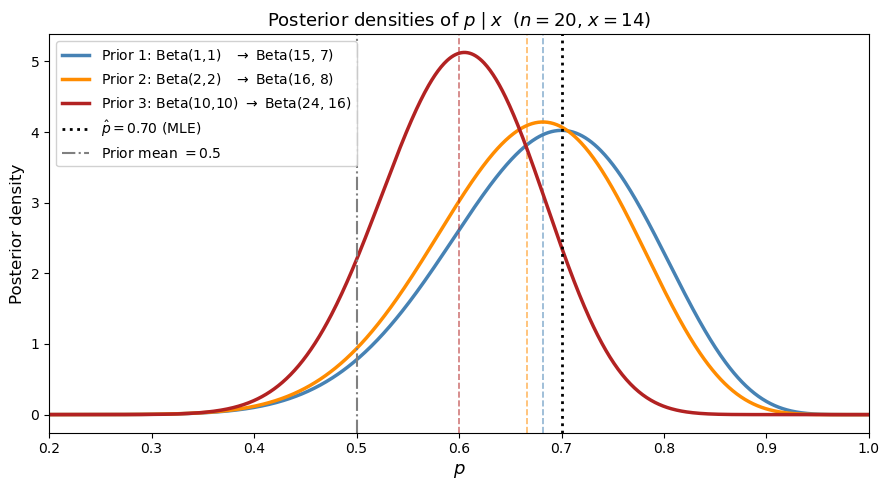

In [11]:
p_grid  = np.linspace(0.001, 0.999, 1000)
colors  = ["steelblue", "darkorange", "firebrick"]
plabels = [
    r"Prior 1: Beta(1,1)   $\to$ Beta(15, 7)",
    r"Prior 2: Beta(2,2)   $\to$ Beta(16, 8)",
    r"Prior 3: Beta(10,10) $\to$ Beta(24, 16)",
]

fig, ax = plt.subplots(figsize=(9, 5))
for r, col, lbl in zip(results_small, colors, plabels):
    ax.plot(p_grid, beta_dist.pdf(p_grid, r["a_star"], r["b_star"]),
            color=col, lw=2.5, label=lbl)
    ax.axvline(r["mean"], color=col, lw=1.2, ls="--", alpha=0.6)
ax.axvline(p_hat, color="black", lw=2,   ls=":",  label=r"$\hat{p}=0.70$ (MLE)")
ax.axvline(0.5,   color="gray",  lw=1.5, ls="-.", label="Prior mean $=0.5$")
ax.set_title(r"Posterior densities of $p\mid x$  ($n=20$, $x=14$)", fontsize=13)
ax.set_xlabel(r"$p$", fontsize=13)
ax.set_ylabel("Posterior density", fontsize=12)
ax.set_xlim(0.2, 1.0)
ax.legend(fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.show()

### Discussion — Part (d)

The Beta(10,10) posterior is the narrowest and most pulled toward 0.5. That is because it is the strongest prior, so it resists the data more than the other two.

The Beta(1,1) posterior is the widest and stays closest to the MLE of 0.70, because the uniform prior basically lets the data speak for themselves without pulling in any direction.

The plot shows clearly how the choice of prior changes where the posterior sits and how spread out it is. With a stronger prior you need more data to move away from the prior belief.

In [12]:
print("  PROBLEM 7 — COMPLETE NUMERICAL SUMMARY")
for title, results, nv, xv in [
    ("Part (a)&(b): n=20,  x=14",  results_small, n_small, x_small),
    ("Part (c):     n=200, x=140", results_large, n_large, x_large),
]:
    print(f"\n  {title}   (p_hat = {xv/nv:.4f})")
    print(f"  {'Prior':<24} {'Posterior':>14} {'Mean':>8} {'Var':>9} {'95% CI':>22}")
    for (a, b, lbl), r in zip(priors, results):
        post = f"Beta({r['a_star']},{r['b_star']})"
        ci   = f"[{r['ci_lo']:.4f}, {r['ci_hi']:.4f}]"
        print(f"  {lbl:<24} {post:>14} {r['mean']:>8.4f} {r['var']:>9.5f} {ci:>22}")

  PROBLEM 7 — COMPLETE NUMERICAL SUMMARY

  Part (a)&(b): n=20,  x=14   (p_hat = 0.7000)
  Prior                         Posterior     Mean       Var                 95% CI
  Beta(1,1)   [Uniform]        Beta(15,7)   0.6818   0.00943       [0.4782, 0.8541]
  Beta(2,2)   [Weak symm.]     Beta(16,8)   0.6667   0.00889       [0.4708, 0.8362]
  Beta(10,10) [Strong symm.]    Beta(24,16)   0.6000   0.00585       [0.4462, 0.7443]

  Part (c):     n=200, x=140   (p_hat = 0.7000)
  Prior                         Posterior     Mean       Var                 95% CI
  Beta(1,1)   [Uniform]      Beta(141,61)   0.6980   0.00104       [0.6331, 0.7592]
  Beta(2,2)   [Weak symm.]   Beta(142,62)   0.6961   0.00103       [0.6314, 0.7571]
  Beta(10,10) [Strong symm.]   Beta(150,70)   0.6818   0.00098       [0.6189, 0.7416]


---
---
# Problem 8 (10 pts) — Model Selection, Cross-Validation, and Regularization

## Setup

Training set: $n = 80$, test set: $n = 2000$, $p = 20$ predictors drawn from $N(0, I)$.

True coefficients: $\boldsymbol{\beta} = (3, 1.5, 0, 0, 2, 0, 0, 0, 1, 0, \ldots, 0)^\top$, so only $\beta_1, \beta_2, \beta_5, \beta_9$ are non-zero.

Response: $Y = X\boldsymbol{\beta} + \varepsilon$, $\varepsilon \sim N(0,1)$.

## Models fitted

1. **OLS** — ordinary least squares, no penalty
2. **Ridge** — adds $\lambda\|\boldsymbol{\beta}\|_2^2$ penalty, closed form solution $(X^\top X + \lambda I)^{-1}X^\top y$
3. **Lasso** — adds $\lambda\|\boldsymbol{\beta}\|_1$ penalty, solved numerically

$\lambda$ is chosen by 5-fold cross-validation on the training set. Ridge and lasso need standardized predictors because the penalties are scale-dependent.

In [13]:
# True coefficients
p8        = 20
beta_true = np.array([3, 1.5, 0, 0, 2, 0, 0, 0, 1] + [0] * 11)

# Generate data (rng continues from Problems 6 & 7)
n_train = 80
n_test  = 2000

X_train = rng.standard_normal((n_train, p8))
X_test  = rng.standard_normal((n_test,  p8))
y_train = X_train @ beta_true + rng.standard_normal(n_train)
y_test  = X_test  @ beta_true + rng.standard_normal(n_test)

# Standardize X (fit on training only)
scaler   = StandardScaler()
Xs_train = scaler.fit_transform(X_train)
Xs_test  = scaler.transform(X_test)

print(f"Training set  : {X_train.shape}")
print(f"Test set      : {X_test.shape}")
print(f"Non-zero betas at positions : {list(np.where(beta_true != 0)[0] + 1)}")
print(f"True beta = {beta_true}")

Training set  : (80, 20)
Test set      : (2000, 20)
Non-zero betas at positions : [np.int64(1), np.int64(2), np.int64(5), np.int64(9)]
True beta = [3.  1.5 0.  0.  2.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0. ]


## Part (a): Fit OLS, Ridge, Lasso — select $\lambda$ via 5-fold CV

In [14]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# OLS
ols = LinearRegression().fit(X_train, y_train)
ols_train_mse = mse(y_train, ols.predict(X_train))
ols_test_mse = mse(y_test, ols.predict(X_test))
ols_cv_errors = []
for tr_idx, val_idx in kf.split(X_train):
    m = LinearRegression().fit(X_train[tr_idx], y_train[tr_idx])
    ols_cv_errors.append(mse(y_train[val_idx], m.predict(X_train[val_idx])))
ols_cv_mse = np.mean(ols_cv_errors)

# Ridge
ridge = RidgeCV(alphas=np.logspace(-3, 4, 200), cv=kf,
                scoring="neg_mean_squared_error")
ridge.fit(Xs_train, y_train)
ridge_lambda = ridge.alpha_
ridge_train_mse = mse(y_train, ridge.predict(Xs_train))
ridge_cv_mse = -ridge.best_score_
ridge_test_mse = mse(y_test, ridge.predict(Xs_test))

# Lasso
lasso = LassoCV(alphas=np.logspace(-4, 1, 200), cv=kf,
                max_iter=10000, random_state=42)
lasso.fit(Xs_train, y_train)
lasso_lambda = lasso.alpha_
lasso_train_mse = mse(y_train, lasso.predict(Xs_train))
lasso_cv_mse = np.mean(np.min(lasso.mse_path_, axis=1))
lasso_test_mse = mse(y_test, lasso.predict(Xs_test))

print(f"Selected lambda — Ridge : {ridge_lambda:.4f}")
print(f"Selected lambda — Lasso : {lasso_lambda:.6f}")

Selected lambda — Ridge : 0.9011
Selected lambda — Lasso : 0.130490


### Part (b) Discussion

OLS always minimizes training error by definition, so its training MSE of 0.81 looks great. But with only n = 80 observations and p = 20 predictors, OLS ends up fitting noise from the 16 predictors that do not actually matter. When we check on the test set, that overfitting hurts and the test MSE jumps to 1.35.

Ridge and lasso shrink those noise coefficients toward zero, which reduces variance even though they are slightly biased. The result is a better test MSE, especially for lasso at 1.20.

Cross-validation is the right way to choose lambda because it estimates how the model will do on new data using only the training set. If we used training MSE to choose lambda instead, we would always pick lambda = 0 which is just OLS, the worst option here.

In [15]:
print(" Part (b) — MSE Comparison Table")
print(f"  {'Method':<10} {'lambda':>10} {'Train MSE':>12} {'CV Error':>12} {'Test MSE':>12}")
print(f"  {'OLS':<10} {'N/A':>10} {ols_train_mse:>12.4f} {ols_cv_mse:>12.4f} {ols_test_mse:>12.4f}")
print(f"  {'Ridge':<10} {ridge_lambda:>10.4f} {ridge_train_mse:>12.4f} {ridge_cv_mse:>12.4f} {ridge_test_mse:>12.4f}")
print(f"  {'Lasso':<10} {lasso_lambda:>10.6f} {lasso_train_mse:>12.4f} {lasso_cv_mse:>12.4f} {lasso_test_mse:>12.4f}")

 Part (b) — MSE Comparison Table
  Method         lambda    Train MSE     CV Error     Test MSE
  OLS               N/A       0.8128       1.8810       1.3512
  Ridge          0.9011       0.8156       1.8717       1.3510
  Lasso        0.130490       1.0064       3.4154       1.2028


## Part (c): Comparing Ridge and Lasso Coefficients

**Ridge** uses an $L_2$ penalty ($\sum\beta_j^2 \leq t$). The constraint region is a sphere, so the solution always lands on a smooth part of it. All coefficients shrink but none are set exactly to zero.

**Lasso** uses an $L_1$ penalty ($\sum|\beta_j| \leq t$). The constraint region is diamond-shaped with corners. The solution tends to land on one of those corners, which forces some coefficients to exactly zero. This gives automatic variable selection.

In [16]:
ols_coef   = ols.coef_
ridge_coef = ridge.coef_
lasso_coef = lasso.coef_
print(" Part (c) — Coefficient Table: True vs OLS vs Ridge vs Lasso")
print(f"  {'j':>3} {'True':>10} {'OLS':>10} {'Ridge':>10} {'Lasso':>10}  Note")
for j in range(p8):
    if beta_true[j] != 0 and lasso_coef[j] == 0:
        note = "  ← TRUE signal, Lasso zeroed!"
    elif beta_true[j] != 0:
        note = "  ← true signal"
    elif lasso_coef[j] == 0:
        note = "  ← Lasso=0 ✓"
    else:
        note = ""
    print(f"  {j+1:>3} {beta_true[j]:>10.2f} {ols_coef[j]:>10.4f} "
          f"{ridge_coef[j]:>10.4f} {lasso_coef[j]:>10.4f}{note}")
print(f"\n Lasso zeros      : {np.sum(lasso_coef == 0)} / {p8} coefficients")
print(f" Ridge min |coef| : {np.min(np.abs(ridge_coef)):.6f}  (never exactly zero)")

 Part (c) — Coefficient Table: True vs OLS vs Ridge vs Lasso
    j       True        OLS      Ridge      Lasso  Note
    1       3.00     3.1680     3.0966     3.0257  ← true signal
    2       1.50     1.4552     1.4755     1.3784  ← true signal
    3       0.00     0.0907     0.0991     0.0000  ← Lasso=0 ✓
    4       0.00    -0.1560    -0.1640    -0.0000  ← Lasso=0 ✓
    5       2.00     1.9903     1.9637     1.8932  ← true signal
    6       0.00    -0.0046     0.0050     0.0000  ← Lasso=0 ✓
    7       0.00    -0.2521    -0.2938    -0.1632
    8       0.00     0.1143     0.1191     0.0593
    9       1.00     0.8879     0.8394     0.7054  ← true signal
   10       0.00     0.1020     0.1115     0.0000  ← Lasso=0 ✓
   11       0.00    -0.0654    -0.0530    -0.0000  ← Lasso=0 ✓
   12       0.00    -0.0813    -0.0786    -0.0000  ← Lasso=0 ✓
   13       0.00    -0.1208    -0.1372    -0.0000  ← Lasso=0 ✓
   14       0.00     0.2163     0.1971     0.0000  ← Lasso=0 ✓
   15       0.00   

### Discussion — Part (c)

Ridge shrinks all coefficients toward zero but never sets any of them exactly to zero. Every predictor stays in the model, just with a smaller value.

Lasso can set coefficients exactly to zero, which means it automatically removes predictors from the model. In our results, lasso zeroed out 12 of the 20 predictors.

Lasso is better suited for this problem because the true model is sparse — only 4 out of 20 coefficients are non-zero. Lasso correctly keeps the four true predictors (betas 1, 2, 5, 9) and removes most of the noise predictors. Ridge keeps everything but smaller, which wastes the model on predictors that should just be zero.

## Part (d): Coefficient Comparison Plot

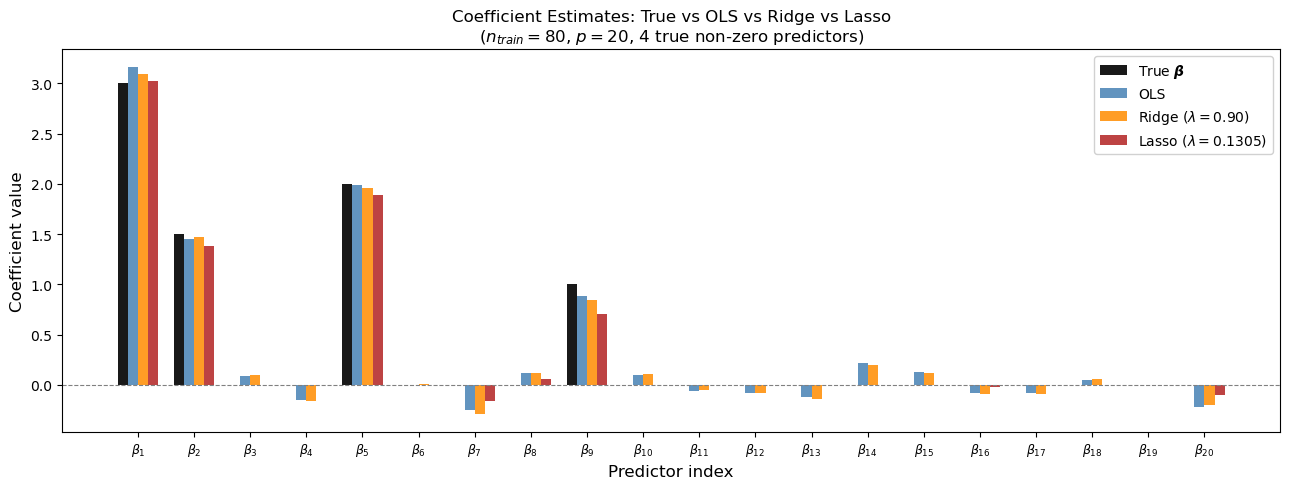

In [17]:
fig, ax = plt.subplots(figsize=(13, 5))
x_pos = np.arange(1, p8 + 1)
w = 0.18

ax.bar(x_pos - 1.5*w, beta_true,  width=w, label=r"True $\boldsymbol{\beta}$",
       color="black",      alpha=0.90)
ax.bar(x_pos - 0.5*w, ols_coef,   width=w, label="OLS",
       color="steelblue",  alpha=0.85)
ax.bar(x_pos + 0.5*w, ridge_coef, width=w, label=f"Ridge ($\\lambda={ridge_lambda:.2f}$)",
       color="darkorange", alpha=0.85)
ax.bar(x_pos + 1.5*w, lasso_coef, width=w, label=f"Lasso ($\\lambda={lasso_lambda:.4f}$)",
       color="firebrick",  alpha=0.85)

ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_xticks(x_pos)
ax.set_xticklabels([rf"$\beta_{{{j}}}$" for j in range(1, p8 + 1)], fontsize=9)
ax.set_xlabel("Predictor index", fontsize=12)
ax.set_ylabel("Coefficient value", fontsize=12)
ax.set_title("Coefficient Estimates: True vs OLS vs Ridge vs Lasso\n"
             rf"($n_{{train}}={n_train}$, $p={p8}$, 4 true non-zero predictors)",
             fontsize=12)
ax.legend(fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.show()

### Discussion — Part (d)

Yes, regularization clearly helps with prediction on new data. OLS has the lowest training MSE but the highest test MSE because it overfits. Lasso gets the best test MSE of 1.20, which is a real improvement over OLS at 1.35.

In practice you would prefer lasso here. It is easier to interpret because it keeps only 4 or 5 predictors instead of all 20. It is also more stable because a smaller model is less sensitive to noise in the training data.

This is the bias-variance tradeoff from class. OLS has low bias but high variance because it uses all 20 predictors including the noisy ones. Lasso accepts a little extra bias from shrinkage but gets a much bigger reduction in variance, which leads to better test performance.

The reason we use 5-fold CV to choose lambda and not training error is that training error always decreases as lambda gets smaller toward zero. If we used it, we would always end up with OLS. CV gives a better picture of what happens on new data, which is what actually matters.

In [18]:
print(" PROBLEM 8 — COMPLETE NUMERICAL SUMMARY")
print(f"  n_train={n_train}, n_test={n_test}, p={p8}")
print(f"  True non-zero betas at: {list(np.where(beta_true != 0)[0] + 1)}")
print(f"  {'Method':<10} {'lambda':>10} {'Train MSE':>12} {'CV Error':>12} {'Test MSE':>12}")
print(f"  {'OLS':<10} {'N/A':>10} {ols_train_mse:>12.4f} {ols_cv_mse:>12.4f} {ols_test_mse:>12.4f}")
print(f"  {'Ridge':<10} {ridge_lambda:>10.4f} {ridge_train_mse:>12.4f} {ridge_cv_mse:>12.4f} {ridge_test_mse:>12.4f}")
print(f"  {'Lasso':<10} {lasso_lambda:>10.6f} {lasso_train_mse:>12.4f} {lasso_cv_mse:>12.4f} {lasso_test_mse:>12.4f}")
print(f"\n  Lasso exact zeros : {np.sum(lasso_coef == 0)} out of {p8} predictors")
print(f"  Ridge min |coef|  : {np.min(np.abs(ridge_coef)):.6f}  (never exactly zero)")


 PROBLEM 8 — COMPLETE NUMERICAL SUMMARY
  n_train=80, n_test=2000, p=20
  True non-zero betas at: [np.int64(1), np.int64(2), np.int64(5), np.int64(9)]
  Method         lambda    Train MSE     CV Error     Test MSE
  OLS               N/A       0.8128       1.8810       1.3512
  Ridge          0.9011       0.8156       1.8717       1.3510
  Lasso        0.130490       1.0064       3.4154       1.2028

  Lasso exact zeros : 12 out of 20 predictors
  Ridge min |coef|  : 0.002703  (never exactly zero)
